# 📋 Fase 0: Auditoría de Imputación

Este notebook responde al manifiesto `00_MANIFESTO_IMPUTATION_AUDIT.md` y evalúa si el dataset es confiable para modelado o si la imputación destruyó la señal original.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from statsmodels.tsa.stattools import acf, pacf

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar configuración (REGLA R7)
with open('../config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Obtenemos la ruta dinámica desde el YAML
file_path = f"../{config['data']['raw']}"

# Cargar dataset (usamos read_csv porque es el crudo)
df = pd.read_csv(file_path, parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df.set_index('fecha', inplace=True)
df.head()

,ayacucho,caicara,ciudad_bolivar,palua
fecha,,,,
1974-01-01,43.34,24.98,6.89,3.83
1974-01-02,43.25,24.88,6.78,3.93
1974-01-03,43.14,24.78,6.73,3.75
1974-01-04,43.04,24.68,6.68,3.49
1974-01-05,42.94,24.58,6.62,3.64


## PC-00-01: Análisis de NaN por Estación

In [7]:
print("Total NaNs por estación:")
print(df.isna().sum())

print("\nFechas de NaNs explícitos en palua:")
palua_nans = df[df['palua'].isna()]
print(palua_nans.index.tolist())

Total NaNs por estación:
ayacucho           0
caicara            0
ciudad_bolivar     0
palua             17
dtype: int64

Fechas de NaNs explícitos en palua:
[Timestamp('1976-02-29 00:00:00'), Timestamp('1980-02-29 00:00:00'), Timestamp('1984-02-29 00:00:00'), Timestamp('1988-02-29 00:00:00'), Timestamp('1992-02-29 00:00:00'), Timestamp('1993-02-27 00:00:00'), Timestamp('1993-02-28 00:00:00'), Timestamp('1993-10-29 00:00:00'), Timestamp('1993-10-30 00:00:00'), Timestamp('1993-10-31 00:00:00'), Timestamp('1996-02-29 00:00:00'), Timestamp('2000-02-29 00:00:00'), Timestamp('2004-02-29 00:00:00'), Timestamp('2008-02-29 00:00:00'), Timestamp('2012-02-29 00:00:00'), Timestamp('2016-02-29 00:00:00'), Timestamp('2020-02-29 00:00:00')]


## PC-00-02: Coincidencia Temporal de Brechas
Dado que solo hay NaNs explícitos en Palúa, buscaremos si las otras estaciones presentan varianza casi nula (líneas rectas) que indiquen imputación plana en periodos simultáneos.

In [8]:
rolling_std = df.rolling(window=7).std()
low_variance = (rolling_std < 0.01).sum()
print("Días con varianza casi nula (posible imputación plana):")
print(low_variance)

Días con varianza casi nula (posible imputación plana):
ayacucho          121
caicara           154
ciudad_bolivar     73
palua              36
dtype: int64


## PC-00-03: Plausibilidad Hidrológica de la Señal

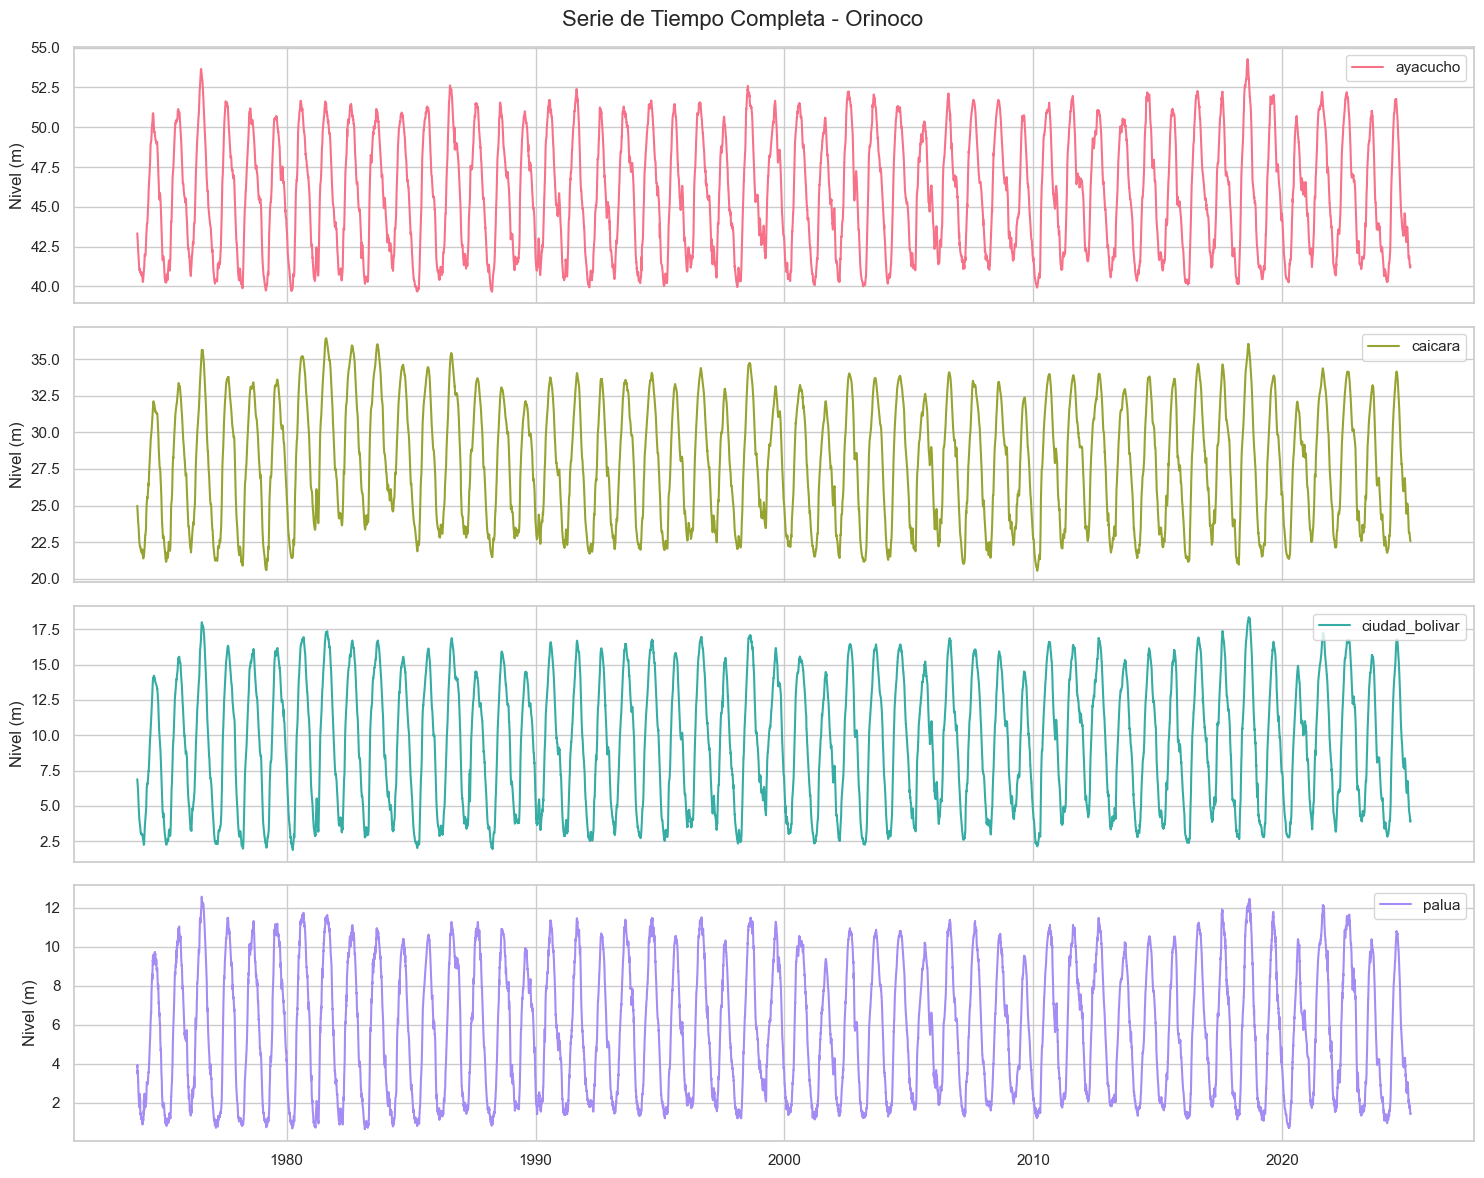


Estadísticas descriptivas:


,ayacucho,caicara,ciudad_bolivar,palua
count,18683.000000,18683.000000,18683.00000,18666.000000
mean,45.871851,27.945825,9.48593,5.745006
std,3.723454,4.163692,4.59593,3.398559
min,39.680000,20.530000,1.88000,0.630000
25%,42.300000,23.940000,5.00000,2.330000
50%,45.820000,28.160000,9.68000,5.560000
75%,49.300000,31.700000,13.72000,8.970000
max,54.280000,36.450000,18.34000,12.580000


In [9]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], label=col, color=sns.color_palette("husl", 4)[i])
    axes[i].legend(loc="upper right")
    axes[i].set_ylabel("Nivel (m)")
plt.suptitle("Serie de Tiempo Completa - Orinoco", fontsize=16)
plt.tight_layout()
plt.show()

print("\nEstadísticas descriptivas:")
display(df.describe())

## PC-00-04: ACF y PACF — Autocorrelación de la Señal

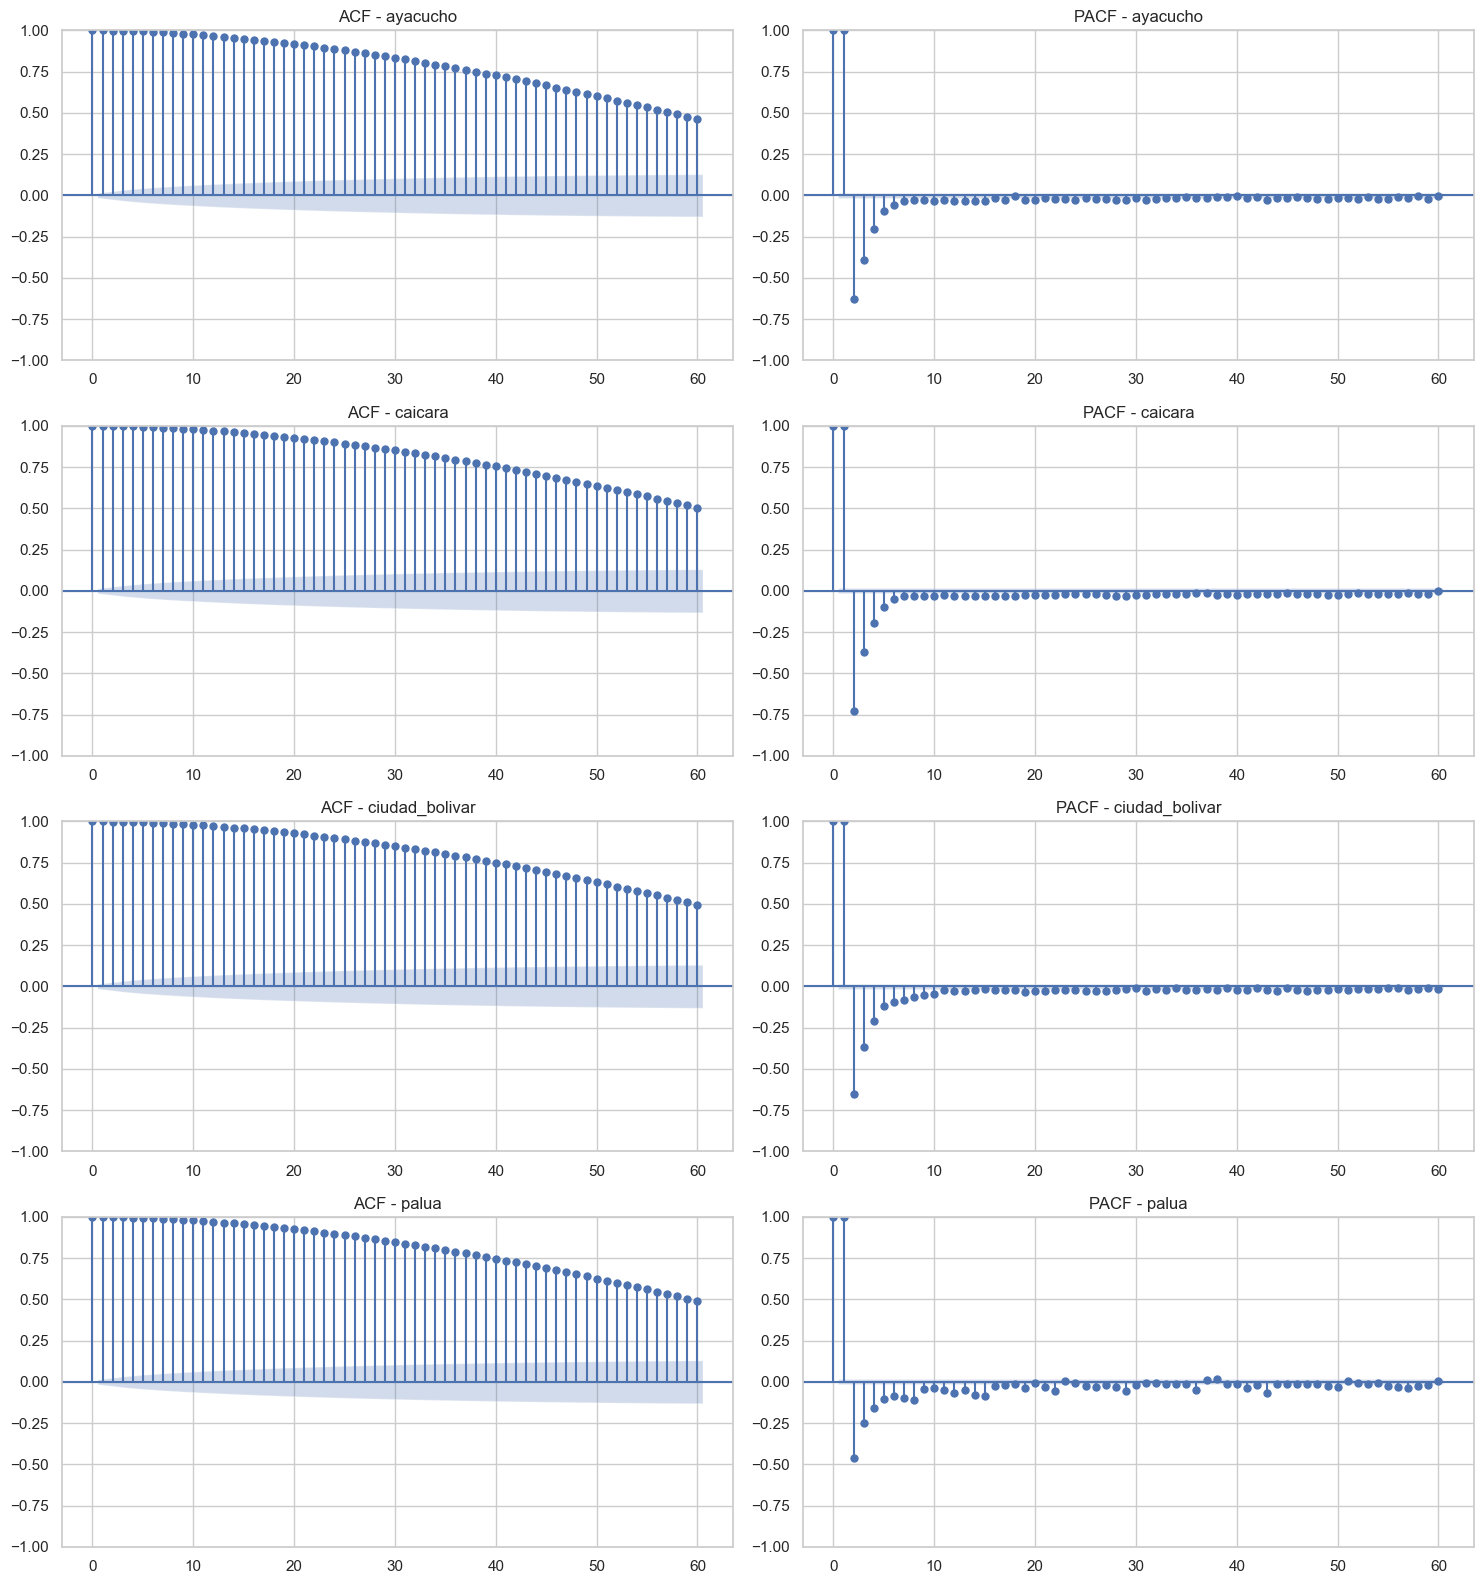

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(len(df.columns), 2, figsize=(15, 4 * len(df.columns)))
for i, col in enumerate(df.columns):
    col_filled = df[col].interpolate()
    plot_acf(col_filled.dropna(), lags=60, ax=axes[i, 0], title=f"ACF - {col}")
    plot_pacf(col_filled.dropna(), lags=60, ax=axes[i, 1], title=f"PACF - {col}")
plt.tight_layout()
plt.show()

## PC-00-05: Cross-Correlation Entre Estaciones
Aquí validaremos el desfase (lag) temporal entre las estaciones midiendo la correlación máxima cruzada.

In [11]:
def get_best_lag(s1, s2, max_lag=30):
    corrs = [s1.shift(lag).corr(s2) if lag > 0 else s1.corr(s2) for lag in range(max_lag + 1)]
    best_lag = np.argmax(corrs)
    return best_lag, corrs[best_lag]

df_filled = df.interpolate()
print("Lags empíricos encontrados (días para máxima correlación):")
print(f"Ayacucho -> Caicara: {get_best_lag(df_filled['ayacucho'], df_filled['caicara'])[0]} días")
print(f"Caicara -> Ciudad Bolivar: {get_best_lag(df_filled['caicara'], df_filled['ciudad_bolivar'])[0]} días")
print(f"Ciudad Bolivar -> Palua: {get_best_lag(df_filled['ciudad_bolivar'], df_filled['palua'])[0]} días")

Lags empíricos encontrados (días para máxima correlación):
Ayacucho -> Caicara: 7 días
Caicara -> Ciudad Bolivar: 4 días
Ciudad Bolivar -> Palua: 0 días


## PC-00-06: Visualización de las Zonas Imputadas Conocidas
Hacemos un zoom sobre la ventana de 1993 donde faltan 2 días en Febrero.

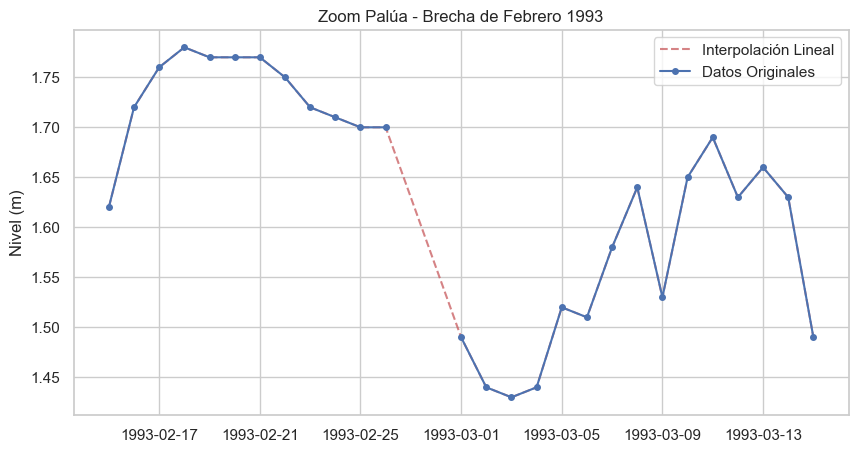

In [12]:
zoom_1993 = df.loc['1993-02-15':'1993-03-15'].copy()
zoom_1993['palua_interpolated'] = zoom_1993['palua'].interpolate()

plt.figure(figsize=(10, 5))
plt.plot(zoom_1993.index, zoom_1993['palua_interpolated'], 'r--', alpha=0.7, label='Interpolación Lineal')
plt.plot(zoom_1993.index, zoom_1993['palua'], 'b-', marker='o', markersize=4, label='Datos Originales')
plt.title("Zoom Palúa - Brecha de Febrero 1993")
plt.ylabel("Nivel (m)")
plt.legend()
plt.show()

## PC-00-07: VEREDICTO
Una vez revisado todo lo anterior, actualiza este JSON para dictaminar qué haremos con el dataset. El agente está esperando que este archivo no diga 'PENDING'.

In [13]:
import json
import os

verdict_data = {
    "verdict": "PENDING", # OPCIONES: "A" (Aceptar), "B" (Re-imputar), "C" (Descartar ventanas)
    "dataset_to_use": "data/processed/dataset_audited.parquet",
    "tests_passed": [],
    "tests_failed": [],
    "justification": "Escribe aquí la justificación basada en los gráficos de arriba.",
    "executed_at": pd.Timestamp.now().strftime("%Y-%m-%d")
}

os.makedirs('../results/metrics', exist_ok=True)
with open('../results/metrics/phase0_verdict.json', 'w') as f:
    json.dump(verdict_data, f, indent=4)
    
print("Archivo phase0_verdict.json generado.\n⚠️ ¡Recuerda cambiar PENDING por el veredicto oficial luego de ejecutar las celdas!")

Archivo phase0_verdict.json generado.
⚠️ ¡Recuerda cambiar PENDING por el veredicto oficial luego de ejecutar las celdas!
